# Etapa 03 — EDA da Silver e protocolo temporal

Preparação de 2026-10-07. Estado: implementação e testes controlados; **execução e verificação informadas pelo autor**.
A Silver completa foi construída pelo autor, conforme o [recibo](../../references/evidence/silver_build_2026-10-06.json).
Esta etapa transforma sua base de consulta em evidências descritivas para decidir a futura Gold.

Referências principais: [EDA](../../docs/EDA.md), [protocolo temporal](../../docs/EVALUATION_PROTOCOL.md) e
[recibo de preparação](../../references/evidence/eda_preparation_2026-10-07.json).


## Decisão antes da exploração

Explorar apenas o treino, de 1 a 28 de abril de 2018. Validação: 6 a 12 de maio;
teste final: 20 a 26 de maio. Entre as janelas, reservar sete dias para chegada dos rótulos.
As datas são escolhas de calendário, sem seleção por taxas de fraude observadas.

O Handbook motiva avaliação cronológica e atraso de feedback. Nosso protocolo inicial
usa quatro semanas de treino e todas as transações, sem bloqueio de clientes comprometidos;
não replica seu benchmark. O futuro modelo será selecionado pela validação, mantendo
as transformações e candidatos ajustados apenas no treino, sem refit antes do teste.

Confira o [JSON versionado](../../references/temporal_protocol_v1.json). Os intervalos no código
incluem `start` e excluem `end_exclusive`. O validador não materializa ainda os splits de modelagem.


## Executar a análise

Na raiz do checkout:

```bash
poetry install
make validate
poetry run python -m fraud_detection_mlops.eda build
```

Preserve o `eda_path` e `audit_path` impressos. Depois execute
`poetry run python -m fraud_detection_mlops.eda verify <eda_path>`.
As células abaixo são opcionais para ler outputs reais; não fazem download nem treinamento.
Use o kernel do ambiente Poetry. Os outputs estão vazios até a execução do autor.


In [1]:
import json

import pandas as pd

from fraud_detection_mlops.profiling import PROJECT_ROOT
from fraud_detection_mlops.temporal import DEFAULT_PROTOCOL

protocol = json.loads(DEFAULT_PROTOCOL.read_text(encoding="utf-8"))
print(json.dumps(protocol["windows"], indent=2))

2026-10-07 10:33:49.395 | INFO     | fraud_detection_mlops.config:<module>:11 - PROJ_ROOT path is: /home/wanderson/Documentos/fraud-detection-mlops


{
  "train": {
    "start": "2018-04-01",
    "end_exclusive": "2018-04-29"
  },
  "validation": {
    "start": "2018-05-06",
    "end_exclusive": "2018-05-13"
  },
  "test": {
    "start": "2018-05-20",
    "end_exclusive": "2018-05-27"
  }
}


## Abrir uma execução específica

Preencha `RUN_ID` com a execução que deseja interpretar. Não selecionamos automaticamente
um relatório por data de modificação: o identificador liga a leitura à auditoria.


In [2]:
from fraud_detection_mlops.eda import verify_eda

RUN_ID = "733686de23204cd6b9a5a1ec1cfbc2e7"
run_path = PROJECT_ROOT / "data/interim/handbook" / protocol["source_commit"] / "eda_v1" / RUN_ID
print(verify_eda(run_path))
report = json.loads((run_path / "report.json").read_text(encoding="utf-8"))
print(json.dumps(report["summary"], indent=2))

{'eda_path': '/home/wanderson/Documentos/fraud-detection-mlops/data/interim/handbook/6e67dbd0a3bfe0d7ec33abc4bce5f37cd4ff0d6a/eda_v1/733686de23204cd6b9a5a1ec1cfbc2e7', 'verified_outputs': 9, 'status': 'success'}
{
  "customers": 4954,
  "distinct_transaction_ids": 268668,
  "first_transaction": "2018-04-01T00:00:31.000",
  "fraud_count": 1505,
  "fraud_rate": 0.0056017092,
  "genuine_count": 267163,
  "last_transaction": "2018-04-28T23:59:27.000",
  "rows": 268668,
  "terminals": 10000,
  "zero_amounts": 4
}


## Volume e prevalência

Observe a taxa diária com seu denominador. Quantas fraudes por dia sustentam a taxa?
Há mudança gradual ao longo das quatro semanas? Há diferenças entre horas e dias da semana?
Uma mudança descritiva não prova drift de desempenho; ainda não há modelo.
O resumo global já conhecido de 0,8369% cobre seis meses, enquanto este relatório cobre o treino.
Não confunda os dois denominadores nem use o número global como resultado da EDA de treino.


In [3]:
for name in ("daily", "hourly", "weekday"):
    print(f"\n{name}")
    print(pd.read_csv(run_path / f"{name}.csv").to_string(index=False))


daily
    period  transactions  frauds  fraud_rate  mean_amount  customers  terminals
2018-04-01          9488       3    0.000316    53.249981       3676       6028
2018-04-02          9583      13    0.001357    52.600467       3695       6089
2018-04-03          9747      15    0.001539    53.831375       3724       6121
2018-04-04          9530      18    0.001889    53.255014       3731       6045
2018-04-05          9651      22    0.002280    53.443085       3759       6087
2018-04-06          9539      27    0.002830    53.174529       3742       6119
2018-04-07          9438      39    0.004132    53.134377       3697       5989
2018-04-08          9468      39    0.004119    53.449256       3716       6009
2018-04-09          9699      40    0.004124    52.656559       3727       6126
2018-04-10          9672      58    0.005997    54.323561       3739       6114
2018-04-11          9622      52    0.005404    53.518359       3696       6113
2018-04-12          9541      42 

## Valores e atividade

A análise preserva zeros e extremos. Compare mediana e caudas por classe, sem transformar
uma faixa do histograma em regra de fraude. A unidade monetária é a da fonte, sem atribuir BRL.
A distribuição de atividade informa se históricos por cliente/terminal têm suporte suficiente.
Esses agregados da janela inteira são diagnósticos; não são features disponíveis no começo da janela.


In [4]:
for name in ("amount_by_label", "amount_bins", "entity_activity", "scenarios_audit_only"):
    print(f"\n{name}")
    print(pd.read_csv(run_path / f"{name}.csv").to_string(index=False))


amount_by_label
 label  transactions  zero_amounts  minimum       mean  std_population  median    p90     p99  maximum
     0        267163             4     0.00  52.999277       39.369964   44.57 109.36 166.660   219.98
     1          1505             0     0.49 154.207322      160.433331   91.92 375.46 734.184   947.40

amount_bins
 label  bin  transactions  label_fraction
     0    0             4        0.000015
     0    1         28592        0.107021
     0    2         50848        0.190326
     0    3         67416        0.252340
     0    4         84737        0.317173
     0    5         35566        0.133125
     1    1            83        0.055150
     1    2           155        0.102990
     1    3           232        0.154153
     1    4           324        0.215282
     1    5           430        0.285714
     1    6           200        0.132890
     1    7            81        0.053821

entity_activity
     entity  entities  minimum      mean  median  p90   

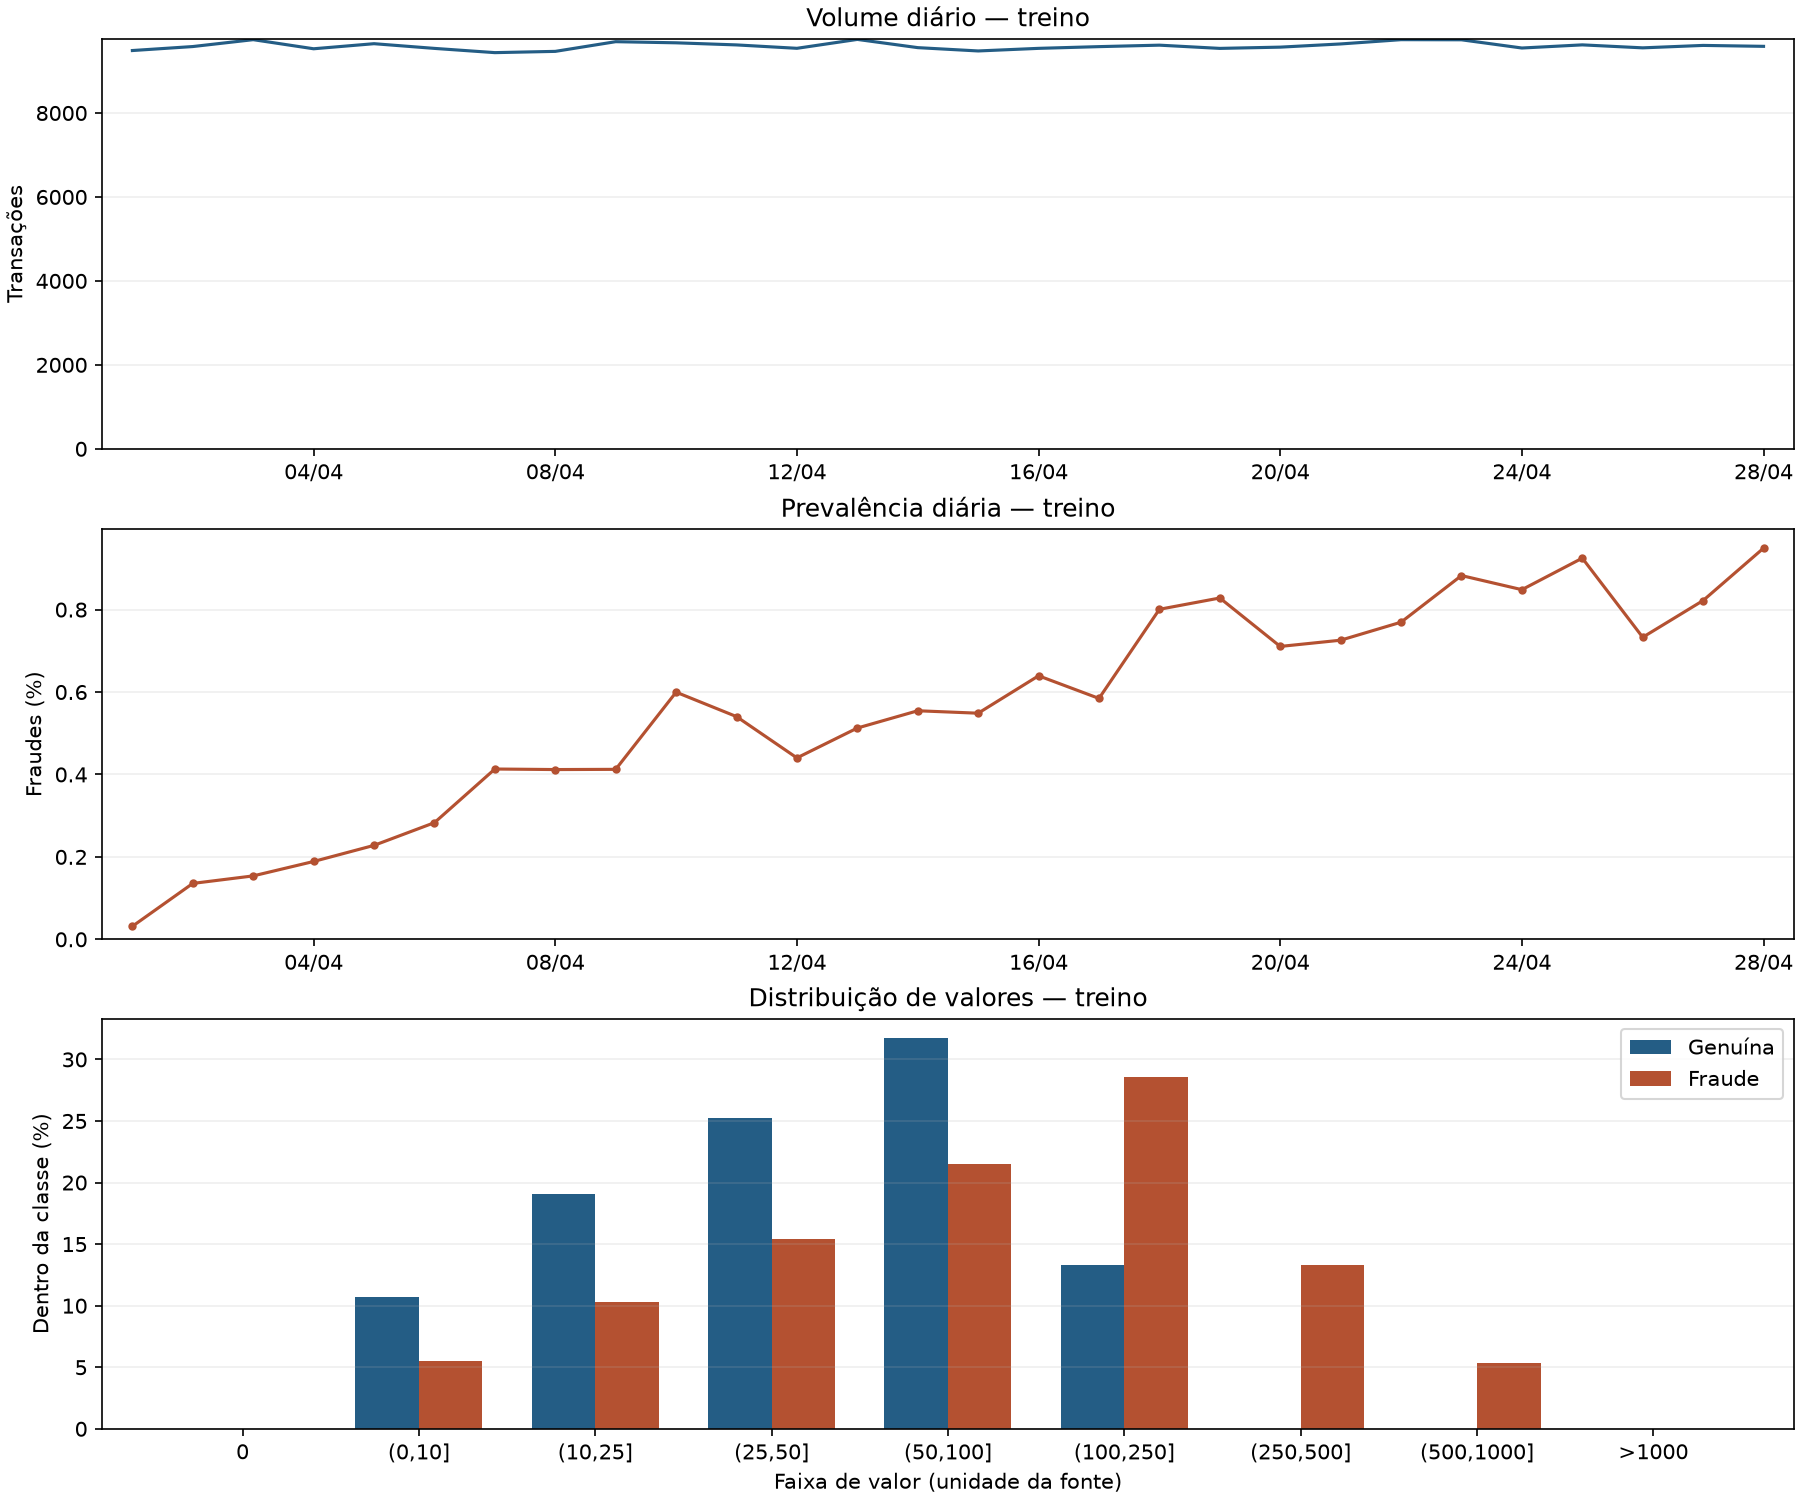

In [5]:
from IPython.display import Image, display

display(Image(filename=str(run_path / "training_overview.png")))

## Achados, hipóteses e limites

**Achados reais informados pelo autor:** run `733686de23204cd6b9a5a1ec1cfbc2e7`,
268.668 transações, 1.505 fraudes, prevalência de 0,5602%, quatro zeros e nove outputs
verificados. O [recibo](../../references/evidence/eda_training_2026-10-07.json) preserva
o resumo e quatro tabelas. A origem é saída de terminal compartilhada; os arquivos
nativos e o painel não foram inspecionados diretamente.

Ao fechar a entrega, associe a revisão avaliada e a CI à evidência. Para ampliar a leitura, registre:

1. Run ID, resumo, checks, versão do código e origem da execução.
2. Principais padrões, incluindo contagens que sustentam taxas e diferenças de valores.
3. Hipóteses para históricos causais de cliente/terminal e suas limitações.
4. O que será comparado exclusivamente na validação.

`TX_FRAUD_SCENARIO` revela informação da simulação e fica fora dos preditores.
IDs brutos não entram no modelo inicial; agrupar histórico é uma responsabilidade diferente.
O treino tem quatro semanas e o teste inicial uma semana: não demonstra estabilidade no restante do semestre.
Transações não são observações independentes; testes inferenciais exigem hipótese e unidade de análise próprias.

A próxima entrega será a Gold com testes de causalidade e atraso dos rótulos. Streaming,
feature store e monitoramento serão avaliados depois do baseline reproduzível.


## Destaque: métricas e interpretação

> O desbalanceamento já mostra por que **acurácia não será nossa métrica principal**: prever todas as transações como genuínas produziria aproximadamente **99,44% de acurácia**, com **recall de fraude igual a zero**. Isso sustenta a escolha de Average Precision para avaliar o ranking.

Esta ilustração foi calculada a partir das contagens de treino; não é uma avaliação de modelo.
Os blocos semanais têm 137, 334, 463 e 571 fraudes, com taxas calculadas por soma
nos respectivos denominadores. O volume diário fica entre 9.438 e 9.753 transações.
Valores fraudulentos têm mediana 91,92 e p99 734,18; genuínos têm mediana 44,57 e p99 166,66.
Há fraude de valor 0,49, portanto valor alto não cobre todas as ocorrências.

Clientes têm mediana de 53 transações no treino, mas mínimo de uma; suporte em janelas curtas
terá que ser verificado. Rótulos finais de cenário: 152, 812 e 541 fraudes nos cenários 1, 2 e 3.
São metadados de auditoria, sujeitos à sobreposição dos mecanismos de geração.

As hipóteses são históricos de volume/valor por cliente e volume/risco conhecido por terminal,
com janelas de 1 e 7 dias, primeiros eventos tratados e rótulos atrasados.
A [referência da EDA](../../docs/EDA.md#achados-informados-pelo-autor-em-2026-10-07)
separa observações, inferências e hipóteses. A Gold ainda será implementada e avaliada.
